In [1]:

import os

CIRCLES_OS_PATH = 'data/circles/'
RECTANGLES_OS_PATH = 'data/rectangles/'
TRIANGLES_OS_PATH = 'data/triangles/'

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

import random

import glob


# Set seed for experimental reproducibility
seed = 1
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1783670925.546028 1132136 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783670925.978768 1132136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783670928.948662 1132136 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Import Dataset

(3000, 240, 320)
rectangle


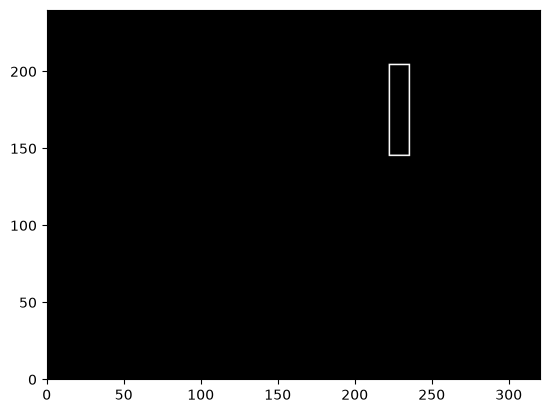

In [ ]:
SAMPLES = 1000
WIDTH = 240 # Change as needed
HEIGHT = 320 # Changed as needed
np.set_printoptions(threshold=np.inf)

def show_screen(axs, screen):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,320,0,240))

label_array = ["circle", "rectangle", "triangle"]
label_to_index = dict((name, index) for index,name in enumerate(label_array))

def get_img(img_path):
    return np.load(img_path)

# Create tuple of whole dataset
def get_ds(data_path):
    labels = np.zeros(SAMPLES*3)
    images = np.zeros((SAMPLES*3, WIDTH, HEIGHT))
    img_paths = list()

    for img_path in glob.glob(F'{data_path}/**/*'):
        img_paths.append(img_path)
  
    random.shuffle(img_paths)
    for i, img_path in enumerate(img_paths):
        images[i] = get_img(img_path)
        head, tail = os.path.split(img_path)
        label_id = tail.split('-')[0]
        labels[i] = label_to_index[label_id]
    
    return images, labels


TRAIN_SPLIT = int(0.6*(SAMPLES*3))
TEST_SPLIT = int(0.2*(SAMPLES*3) + TRAIN_SPLIT)

full_x, full_y = get_ds('data')

x_train, x_test, x_validate = np.split(full_x, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(full_y, [TRAIN_SPLIT, TEST_SPLIT])

show_screen(plt, x_validate[4])
print(label_array[int(y_validate[4])])




# Create The Model

In [20]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 238, 318, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 119, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 117, 157, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 58, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 76, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 38, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 34048)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,358,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,475 (16.70 MB)

 Trainable params: 4,377,475 (16.70 MB)

 Non-trainable params: 0 (0.00 B)

## Train The Model

In [7]:
history = model.fit(
    x_train, y_train, epochs=10, validation_data=(x_validate, y_validate)
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 617ms/step - accuracy: 0.5839 - loss: 0.8256 - val_accuracy: 0.7583 - val_loss: 0.4902
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 623ms/step - accuracy: 0.8333 - loss: 0.3378 - val_accuracy: 0.7867 - val_loss: 0.4453
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 602ms/step - accuracy: 0.9483 - loss: 0.1446 - val_accuracy: 0.7983 - val_loss: 0.6752
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 610ms/step - accuracy: 0.9756 - loss: 0.0847 - val_accuracy: 0.8200 - val_loss: 0.6118
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 610ms/step - accuracy: 0.9883 - loss: 0.0399 - val_accuracy: 0.8283 - val_loss: 0.7046
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 607ms/step - accuracy: 0.9944 - loss: 0.0219 - val_accuracy: 0.8283 - val_loss: 0.7761
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 580ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.8267 - val_loss: 0.9671
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 584ms/step - accuracy: 0.9994 - loss: 0.0041 - val_accu

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step
[-6.681607   9.569811  -6.8377485]


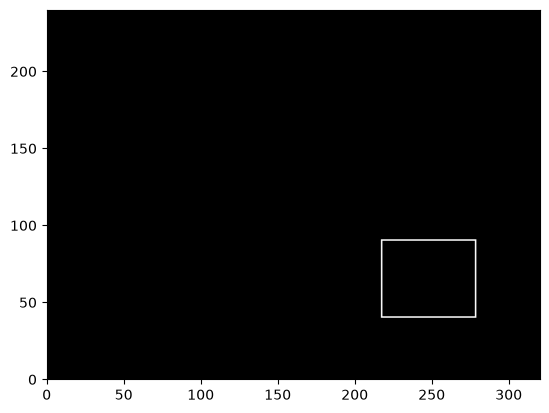

In [15]:
predictions = model.predict(x_test)
print(predictions[3])
show_screen(plt, x_test[3])
